# Tech CEOs Network Simulation
Group Assignment for Computational Modelling of Social System
Group: 21

## Research question:
TBD --> Technology elites diffusion of politcal and societal influence network

## Model
1. Network of CEOs and companies
2. Node power
3. Node threshold
4. Weighted power threshold diffusion
5. Scenario comparison different points
6. random baseline comparison


In [1]:
#libraries

from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.centrality import eigenvector

random.seed(67)
np.random.seed(67)

output_directory = Path("outputs_assignment")
output_directory.mkdir(parents=True, exist_ok=True)

## Creating the Nodes of the Network
Each node is a person, company, institution etc.

- power: 0-1 score is the ability of influence
- threshold: "The number or proportion of others who must make one decision before a given actor does so", (Granovetter, 1978)
- infrastructure_power: how much the node functions as a platform, surveillance system, Ai system or has importance in coordinating societies infrastructures

We formulated these assumption ourselves.

In [2]:
nodes = pd.DataFrame ([
    #Paypal Mafia actors
    {"name": "Elon Musk", "type":"person","group":"paypal mafia", "power": 1.00, "threshold":0.35},
    {"name":"Peter Thiel","type":"person","group":"paypal mafia", "power": 0.90, "threshold":0.35},
    {"name":"David Sacks","type":"person","group":"paypal mafia", "power": 0.65, "threshold":0.35},
    {"name":"Reid Hoffman","type":"person","group":"paypal mafia", "power": 0.60, "threshold":0.50},
    {"name":"Max Levchin","type":"person","group":"paypal mafia", "power": 0.55, "threshold":0.45},

    #Other tech
    {"name": "Sam Altman", "type":"person","group":"tech", "power": 0.72, "threshold":0.55},
    {"name":"Ben Horowitz","type":"person","group":"tech", "power": 0.70, "threshold":0.40},
    {"name":"Marc Andreessen","type":"person","group":"tech", "power": 0.75, "threshold":0.40},
    {"name":"Palmer Luckey","type":"person","group":"tech", "power": 0.55, "threshold":0.35},

    #Politician
    {"name": "Donald Trump", "type":"person","group":"government", "power": 1.00, "threshold":0.50},
    {"name":"JD Vance","type":"person","group":"government", "power": 0.85, "threshold":0.45},

   #Companies, organizations etc.
    {"name": "Paypal", "type":"organization","group":"company", "power": 0.75, "threshold":0.50},
     {"name": "Palantir", "type":"organization","group":"company", "power": 0.80, "threshold":0.45},
    {"name": "Space X", "type":"organization","group":"company", "power": 0.80, "threshold":0.45},
     {"name": "Tesla", "type":"organization","group":"company", "power": 0.50, "threshold":0.40},
    {"name": "Twitter X", "type":"organization","group":"media_platform", "power": 0.80, "threshold":0.40},
     {"name": "Founders Fund", "type":"organization","group":"investment_firm", "power": 0.70, "threshold":0.45},
    {"name": "Andreessen Horowitz", "type":"organization","group":"investment_firm", "power": 0.80, "threshold":0.45},
    {"name": "Anduril", "type":"organization","group":"company", "power": 0.70, "threshold":0.40},
    {"name": "Open AI", "type":"organization","group":"AI_infrastructure", "power": 0.90, "threshold":0.55},
    {"name": "Chat GPT", "type":"organization","group":"AI_infrastructure", "power": 0.80, "threshold":0.55},
    {"name": "US government", "type":"institution","group":"government_politics", "power": 1.00, "threshold":0.60},
    {"name": "Trump Campaign", "type":"organization","group":"government_politics", "power": 0.80, "threshold":0.45},
    {"name": "Defense state", "type":"institution","group":"government_politics", "power": 0.95, "threshold":0.55},
    {"name": "Public", "type":"institution","group":"society", "power": 0.85, "threshold":0.60},

])

infrastructure_power = {
    "Chat GPT":1.00,
    "Open AI": 0.90,
    "Palantir": 0.95,
    "Twitter X": 0.80,
    "Space X":0.85,
    "Defense state":0.85,
    "US government":0.80,
    "Public":0.80,
    "Anduril":0.70,
    "Tesla":0.65,
    "Paypal": 0.55,
    "Founders Fund":0.45,
    "Andreessen Horowitz":0.45,
}

nodes

,name,type,group,power,threshold
0,Elon Musk,person,paypal mafia,1.00,0.35
1,Peter Thiel,person,paypal mafia,0.90,0.35
2,David Sacks,person,paypal mafia,0.65,0.35
3,Reid Hoffman,person,paypal mafia,0.60,0.50
4,Max Levchin,person,paypal mafia,0.55,0.45
5,Sam Altman,person,tech,0.72,0.55
6,Ben Horowitz,person,tech,0.70,0.40
7,Marc Andreessen,person,tech,0.75,0.40
8,Palmer Luckey,person,tech,0.55,0.35
9,Donald Trump,person,government,1.00,0.50


In [3]:
edges = pd.DataFrame([
    #Paypal
    {"source": "Elon Musk", "target": "Paypal", "relation": "founder_or_executive", "weight": 0.90},
    {"source": "Peter Thiel", "target": "Paypal", "relation": "founder_or_executive", "weight": 0.90},
    {"source": "David Sacks", "target": "Paypal", "relation": "executive", "weight": 0.75},
    {"source": "Reid Hoffman", "target": "Paypal", "relation": "executive", "weight": 0.70},
    {"source": "Max Levchin", "target": "Paypal", "relation": "founder_or_executive", "weight": 0.80},
    {"source": "Elon Musk", "target": "David Sacks", "relation": "paypal_network", "weight": 0.60},
    {"source": "Peter Thiel", "target": "David Sacks", "relation": "paypal_network", "weight": 0.60},

    # Business ties
    {"source": "Peter Thiel", "target": "Founders Fund", "relation": "founder", "weight": 0.90},
    {"source": "Peter Thiel", "target": "Palantir", "relation": "founder", "weight": 0.90},
    {"source": "Elon Musk", "target": "Space X", "relation": "founder_or_executive", "weight": 0.90},
    {"source": "Elon Musk", "target": "Tesla", "relation": "executive", "weight": 0.85},
    {"source": "Elon Musk", "target": "Twitter X", "relation": "ownership_or_control", "weight": 0.90},
    {"source": "Marc Andreessen", "target": "Andreessen Horowitz", "relation": "founder", "weight": 0.90},
    {"source": "Ben Horowitz", "target": "Andreessen Horowitz", "relation": "founder", "weight": 0.90},
    {"source": "Palmer Luckey", "target": "Anduril", "relation": "founder", "weight": 0.90},
    {"source": "Sam Altman", "target": "Open AI", "relation": "executive", "weight": 0.85},
    {"source": "Open AI", "target": "Chat GPT", "relation": "product_or_platform", "weight": 0.95},
    {"source": "Founders Fund", "target": "Anduril", "relation": "investment", "weight": 0.65},
    {"source": "Founders Fund", "target": "Space X", "relation": "investment", "weight": 0.55},
    {"source": "Andreessen Horowitz", "target": "Founders Fund", "relation": "vc_ecosystem", "weight": 0.45},
    {"source": "Andreessen Horowitz", "target": "Open AI", "relation": "ai_ecosystem", "weight": 0.40},
    {"source": "Marc Andreessen", "target": "Peter Thiel", "relation": "tech_vc_network", "weight": 0.45},
    {"source": "Marc Andreessen", "target": "Elon Musk", "relation": "tech_vc_network", "weight": 0.35},

    # Political ties
    {"source": "Peter Thiel", "target": "JD Vance", "relation": "political_support", "weight": 0.80},
    {"source": "JD Vance", "target": "Donald Trump", "relation": "administration_or_campaign", "weight": 0.85},
    {"source": "Donald Trump", "target": "Trump Campaign", "relation": "campaign", "weight": 0.90},
    {"source": "Donald Trump", "target": "US government", "relation": "public_office", "weight": 0.90},
    {"source": "JD Vance", "target": "US government", "relation": "public_office", "weight": 0.85},
    {"source": "Elon Musk", "target": "Donald Trump", "relation": "political_alignment_or_support", "weight": 0.70},
    {"source": "David Sacks", "target": "Donald Trump", "relation": "political_alignment_or_advisory", "weight": 0.70},
    {"source": "David Sacks", "target": "Trump Campaign", "relation": "fundraising_or_campaign_support", "weight": 0.65},
    {"source": "Marc Andreessen", "target": "Trump Campaign", "relation": "political_support", "weight": 0.55},
    {"source": "Ben Horowitz", "target": "Trump Campaign", "relation": "political_support", "weight": 0.50},
    {"source": "Twitter X", "target": "Trump Campaign", "relation": "media_platform_attention", "weight": 0.45},
    {"source": "Twitter X", "target": "Public", "relation": "public_discourse_platform", "weight": 0.75},

    # Government contracting, institutional ties
    {"source": "Anduril", "target": "Defense state", "relation": "government_contracting", "weight": 0.72},
    {"source": "Palantir", "target": "Defense state", "relation": "government_contracting", "weight": 0.78},
    {"source": "Space X", "target": "US government", "relation": "government_contracting", "weight": 0.75},
    {"source": "Defense state", "target": "US government", "relation": "state_institution", "weight": 0.80},
    {"source": "Open AI", "target": "US government", "relation": "ai_policy_or_governance", "weight": 0.45},
    {"source": "Chat GPT", "target": "Public", "relation": "information_access", "weight": 0.65},
    {"source": "Palantir", "target": "US government", "relation": "state_data_infrastructure", "weight": 0.70},
])

edges

,source,target,relation,weight
0,Elon Musk,Paypal,founder_or_executive,0.90
1,Peter Thiel,Paypal,founder_or_executive,0.90
2,David Sacks,Paypal,executive,0.75
3,Reid Hoffman,Paypal,executive,0.70
4,Max Levchin,Paypal,founder_or_executive,0.80
5,Elon Musk,David Sacks,paypal_network,0.60
6,Peter Thiel,David Sacks,paypal_network,0.60
7,Peter Thiel,Founders Fund,founder,0.90
8,Peter Thiel,Palantir,founder,0.90
9,Elon Musk,Space X,founder_or_executive,0.90


In [4]:
nodes["infrastructure_power"] = nodes["name"].map(infrastructure_power).fillna(0.25)
G = nx.from_pandas_edgelist(
    edges, source= "source", target= "target",
    edge_attr=["relation", "weight"], create_using=nx.Graph()
)

G.add_nodes_from(nodes["name"])
node_attribute = nodes.set_index("name").to_dict("index")
nx.set_node_attributes(G, node_attribute)

print("Number of nodes: ", len(G.nodes))
print("Number of edges: ", len(G.edges))

Number of nodes:  25
Number of edges:  42


In [5]:
node_names = set(nodes["name"])

print("Missing sources:", set(edges["source"]) - node_names)
print("Missing targets:", set(edges["target"]) - node_names)


Missing sources: set()
Missing targets: set()


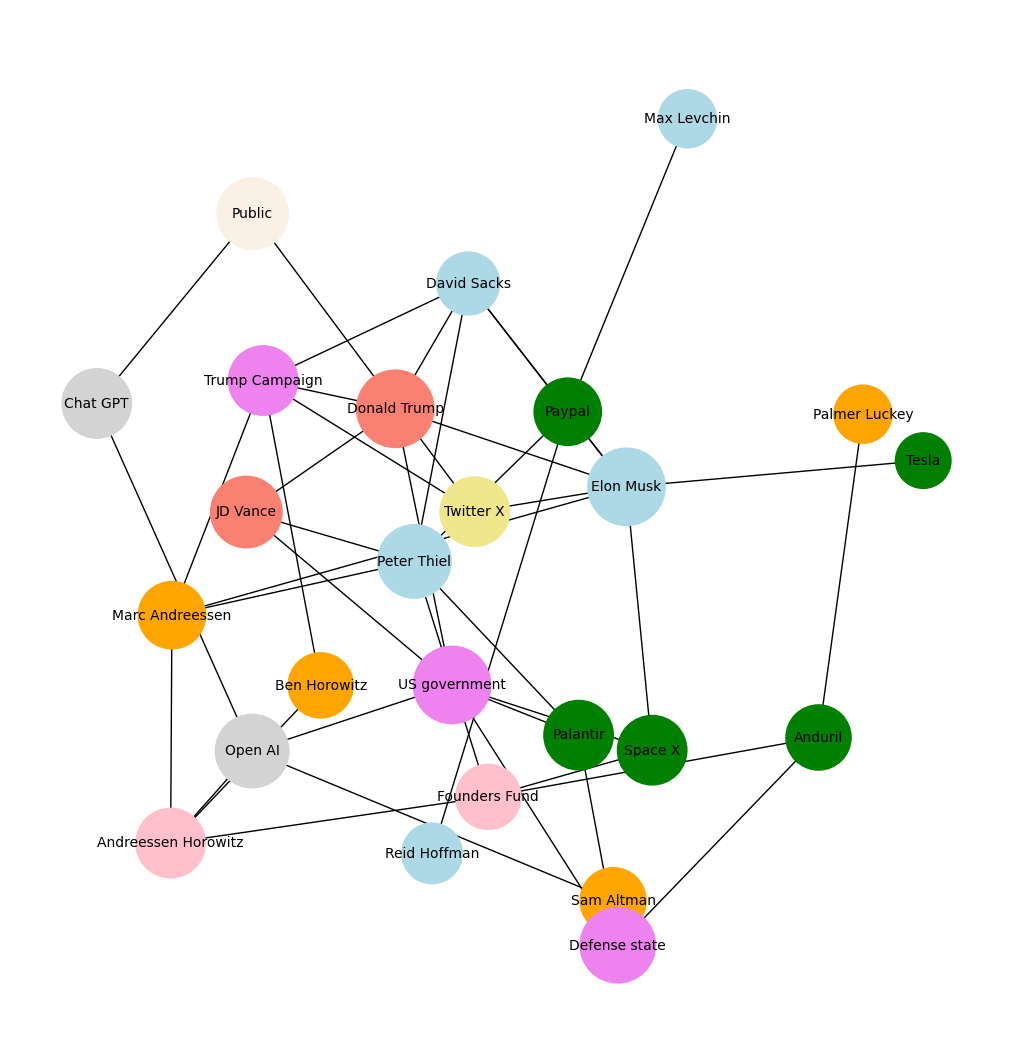

In [6]:
group_colours = {
    "paypal mafia": "lightblue",
    "tech": "orange",
    "government": "salmon",
    "government_politics":"violet",
    "company": "green",
    "AI_infrastructure": "lightgray",
    "media_platform": "khaki",
    "investment_firm": "pink",
    "society": "linen",
}

pos = nx.spring_layout(G, seed=10, k=1.5, iterations=100)

colors = [group_colours.get(G.nodes[n]["group"],"yellow")for n in G.nodes()]
size = [100 +3000 * G.nodes[n]["power"] for n in G.nodes()] #the bigger the power the bigger the node
plt.figure(figsize=(10, 10))
nx.draw(G, pos=pos, with_labels=True,node_size=size,node_color=colors, font_size=10)
plt.title("People and organizations and tech-political network")
plt.axis("off")
plt.show()

# Centrality analysis
Showing the structural position of the network


In [11]:
for u, v, data in G.edges(data=True):
    w = data["weight"]
    if w <= 0:
        raise ValueError("Error")
    data["distance"] = 1 / w

degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight="distance")
eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)
closeness = nx.closeness_centrality(G, distance="distance")

centrality = pd.DataFrame({
    "name": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "power": [G.nodes[n]["power"] for n in G.nodes()],
    "threshold": [G.nodes[n]["threshold"] for n in G.nodes()],
})

centrality = centrality.merge(nodes[["name", "type", "group"]], on="name")
centrality = centrality.sort_values("betweenness", ascending=False)

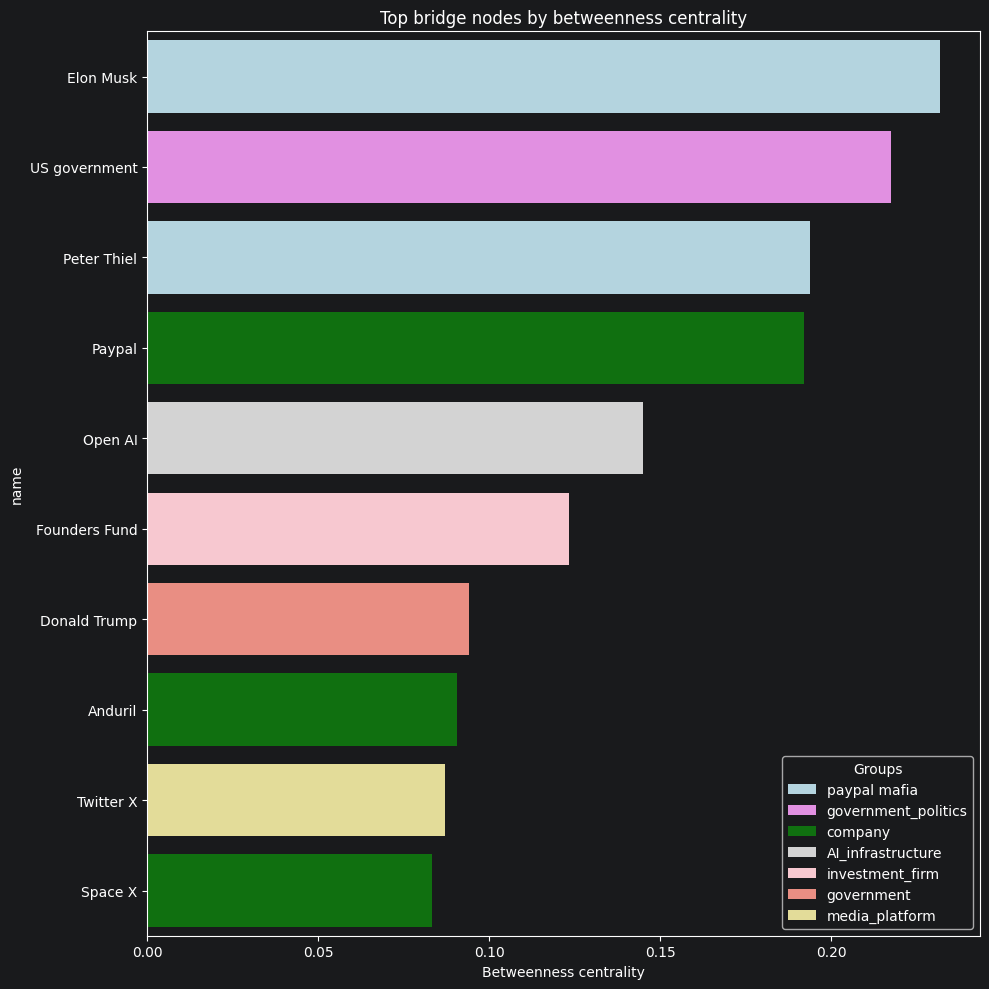

In [12]:
top = centrality.head(10).copy()
plt.figure(figsize=(10, 10))
sns.barplot(data = top, y="name", x="betweenness", hue="group", palette=group_colours)
plt.title("Top bridge nodes by betweenness centrality")
plt.xlabel("Betweenness centrality")
plt.legend(title="Groups")
plt.tight_layout()
plt.show()

# Weighted power threshold diffusion
Linear weighted threshold model:
"Defines a threshold-based behavior, where the influence accumulates from multiple neighbors of the node, which becomes activated only if the cumulative influence passed a certain threshold."(Goldenberg, 2021,https://medium.com/data-science/social-network-analysis-from-theory-to-applications-with-python-d12e9a34c2c7)

active_influence = edge_weight x (power + 0.5 x infrastructure_power)

Total possible influence:

total_influence =  edge_weight x (power + 0.5 x infrastructure_power)

Node adopts when:
active_influence / total_influence >= threshold

Infrastructures such as ChatGPT, government institutions propagate influence more strongly than other nodes.


In [68]:
def weighted_diffusion (G, seeds, max_steps=20):
    active = set(seeds)
    history = []
    events = []

    history.append({
        "step":0,
        "active_count": len(active),
        "new_nodes": ",".join(sorted(active))
    })

    for seed in active:
        events.append({
            "step":0,
            "node": seed,
            "adoption_ratio": 1.0,
            "threshold": G.nodes[seed]["threshold"],
            "reason":"seed",
        })


    for step in range(1,max_steps + 1):
        new_active = set(active)
        activated_this_step = []

        for node in G.nodes():
            if node in active:
                continue

            total_influence= 0.0
            active_influence = 0.0

            for neighbor in G.neighbors(node):
                edge_weight = G[node][neighbor]["weight"]
                source_power = G.nodes[neighbor]["power"]
                source_infrastructure = G.nodes[neighbor]["infrastructure_power"]

                influence_capa = source_power + 0.5 * source_infrastructure
                contribution = edge_weight * influence_capa

                total_influence += contribution

                if neighbor in active:
                    active_influence += contribution

            if total_influence == 0:
                adoption_ratio = 0.0
            else:
                adoption_ratio = active_influence/total_influence

            threshold = G.nodes[node]["threshold"]

            if adoption_ratio > threshold:
                new_active.add(node)
                activated_this_step.append(node)
                events.append({
                    "step":step,
                    "node": node,
                    "adoption_ratio": adoption_ratio,
                    "threshold": threshold,
                    "reason":"enough_active_neighbours"
                })

        if not activated_this_step:
             break

        active = new_active

        history.append({
            "step":step,
            "active_count": len(active),
            "new_nodes": ",".join(activated_this_step),
        })
    return pd.DataFrame(history), pd.DataFrame(events), active



In [69]:
paypal_seeds = ["Elon Musk", "Peter Thiel", "David Sacks"] # already active from beginning core Paypal actors

paypal_history, paypal_events, paypal_active = weighted_diffusion(G, paypal_seeds)

paypal_history
paypal_events

,step,node,adoption_ratio,threshold,reason
0,0,David Sacks,1.000000,0.35,seed
1,0,Peter Thiel,1.000000,0.35,seed
2,0,Elon Musk,1.000000,0.35,seed
3,1,Paypal,0.706068,0.50,enough_active_neighbours
4,1,Tesla,1.000000,0.40,enough_active_neighbours
5,1,Twitter X,0.427892,0.40,enough_active_neighbours
6,2,Reid Hoffman,1.000000,0.50,enough_active_neighbours
7,2,Max Levchin,1.000000,0.45,enough_active_neighbours


In [72]:
active_nodes = nodes[nodes["name"].isin(paypal_active)].sort_values(["group","name"])
print("Final active nodes", len(paypal_active), (G.number_of_nodes()))

active_nodes[["name", "type","group","infrastructure_power", "threshold"]]

Final active nodes 8 25


,name,type,group,infrastructure_power,threshold
11,Paypal,organization,company,0.55,0.50
14,Tesla,organization,company,0.65,0.40
15,Twitter X,organization,media_platform,0.80,0.40
2,David Sacks,person,paypal mafia,0.25,0.35
0,Elon Musk,person,paypal mafia,0.25,0.35
4,Max Levchin,person,paypal mafia,0.25,0.45
1,Peter Thiel,person,paypal mafia,0.25,0.35
3,Reid Hoffman,person,paypal mafia,0.25,0.50


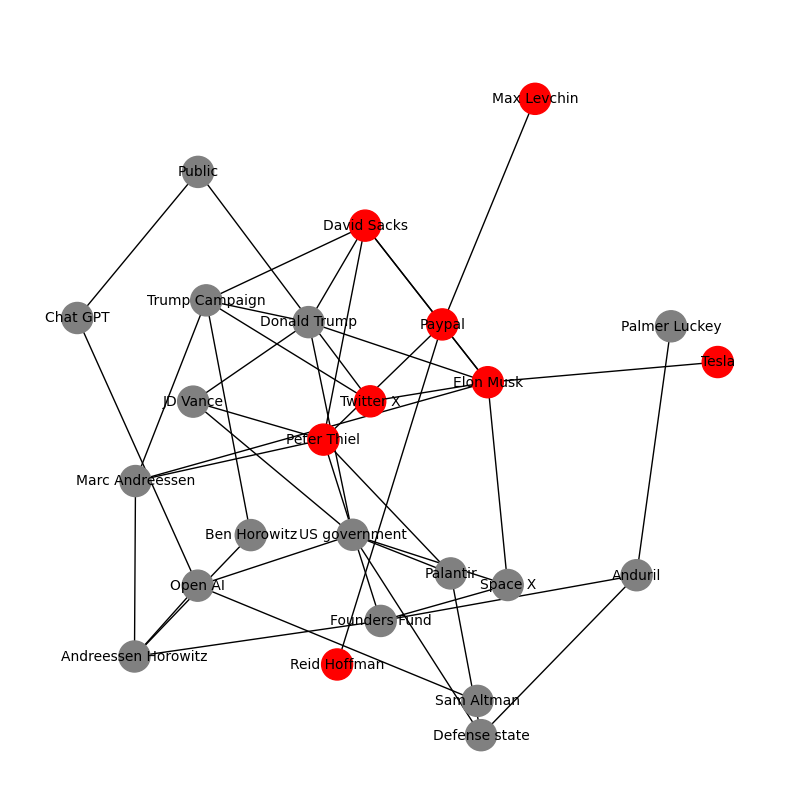

In [82]:
active = ["red" if n in paypal_active else "gray" for n in G.nodes()]

pos = nx.spring_layout(G, seed= 10, k= 1.5, iterations=100)
plt.figure(figsize=(10, 10))
plt.title("Diffusion active nodes red")
nx.draw(G, pos=pos, with_labels=True,node_size=500,node_color=active, font_size=10)
plt.show()

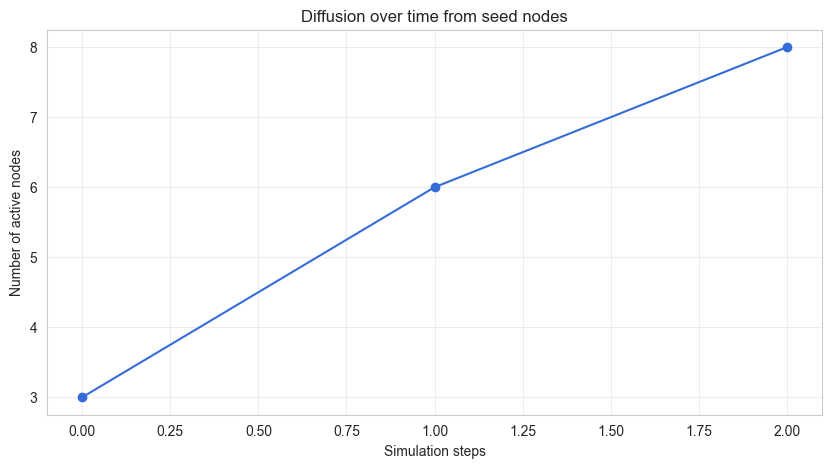

In [121]:
plt.figure(figsize=(10, 5))
plt.plot(paypal_history["step"],
         paypal_history["active_count"],
         marker="o")

sns.set_style("whitegrid")
plt.xlabel("Simulation steps")
plt.ylabel("Number of active nodes")
plt.title("Diffusion over time from seed nodes")
plt.show()

# Scenarios
comparing different starting points

In [102]:
scenario_seeds = {
    "Paypal 'Mafia'" : ["Elon Musk", "Peter Thiel", "David Sacks"],
    "Musk ecosystem": ["Elon Musk", "Space X", "Twitter X"],
    "Thiel ecosystem": ["Peter Thiel", "Founders Fund", "Palantir"],
    "AI infrastructures": ["Sam Altman","Open AI", "Chat GPT"],
    "Platforms and public": ["Elon Musk", "Twitter X", "Public"],
    "Venture Capital, Defense Tech": ["Marc Andreessen", "Ben Horowitz", "Palmer Luckey"],
    "Government": ["Donald Trump", "JD Vance", "Trump Campaign"]
}

scenarios_list = []
curves = []

for scenario, seeds in scenario_seeds.items():
    history, events, active = weighted_diffusion(G, seeds)

    government_nodes = [
        n for n in active if G.nodes[n]["group"]in ["government", "government_politics"]
    ]
    scenarios_list.append({
        "scenario": scenario,
        "seeds": ",".join(seeds),
        "final_active_count": len(active),
        "steps": int(history["step"].max()),
        "government_nodes_reached": len(government_nodes),
        "us_government_reached":int("US government" in active),
        "public_sphere_reached": int("Public" in active),
    })

    for n, row in history.iterrows():
        curves.append({
            "scenario": scenario,
            "step":int(row["step"]),
            "active_count":int(row["active_count"]),
        })


scenarios_results = pd.DataFrame(scenarios_list).sort_values("final_active_count",ascending=False)
scenario_curves = pd.DataFrame(curves)

scenarios_results



,scenario,seeds,final_active_count,steps,government_nodes_reached,us_government_reached,public_sphere_reached
0,Paypal 'Mafia',"Elon Musk,Peter Thiel,David Sacks",8,2,0,0,0
1,Musk ecosystem,"Elon Musk,Space X,Twitter X",4,1,0,0,0
4,Platforms and public,"Elon Musk,Twitter X,Public",4,1,0,0,1
5,"Venture Capital, Defense Tech","Marc Andreessen,Ben Horowitz,Palmer Luckey",4,1,0,0,0
6,Government,"Donald Trump,JD Vance,Trump Campaign",4,1,3,0,0
2,Thiel ecosystem,"Peter Thiel,Founders Fund,Palantir",3,0,0,0,0
3,AI infrastructures,"Sam Altman,Open AI,Chat GPT",3,0,0,0,0


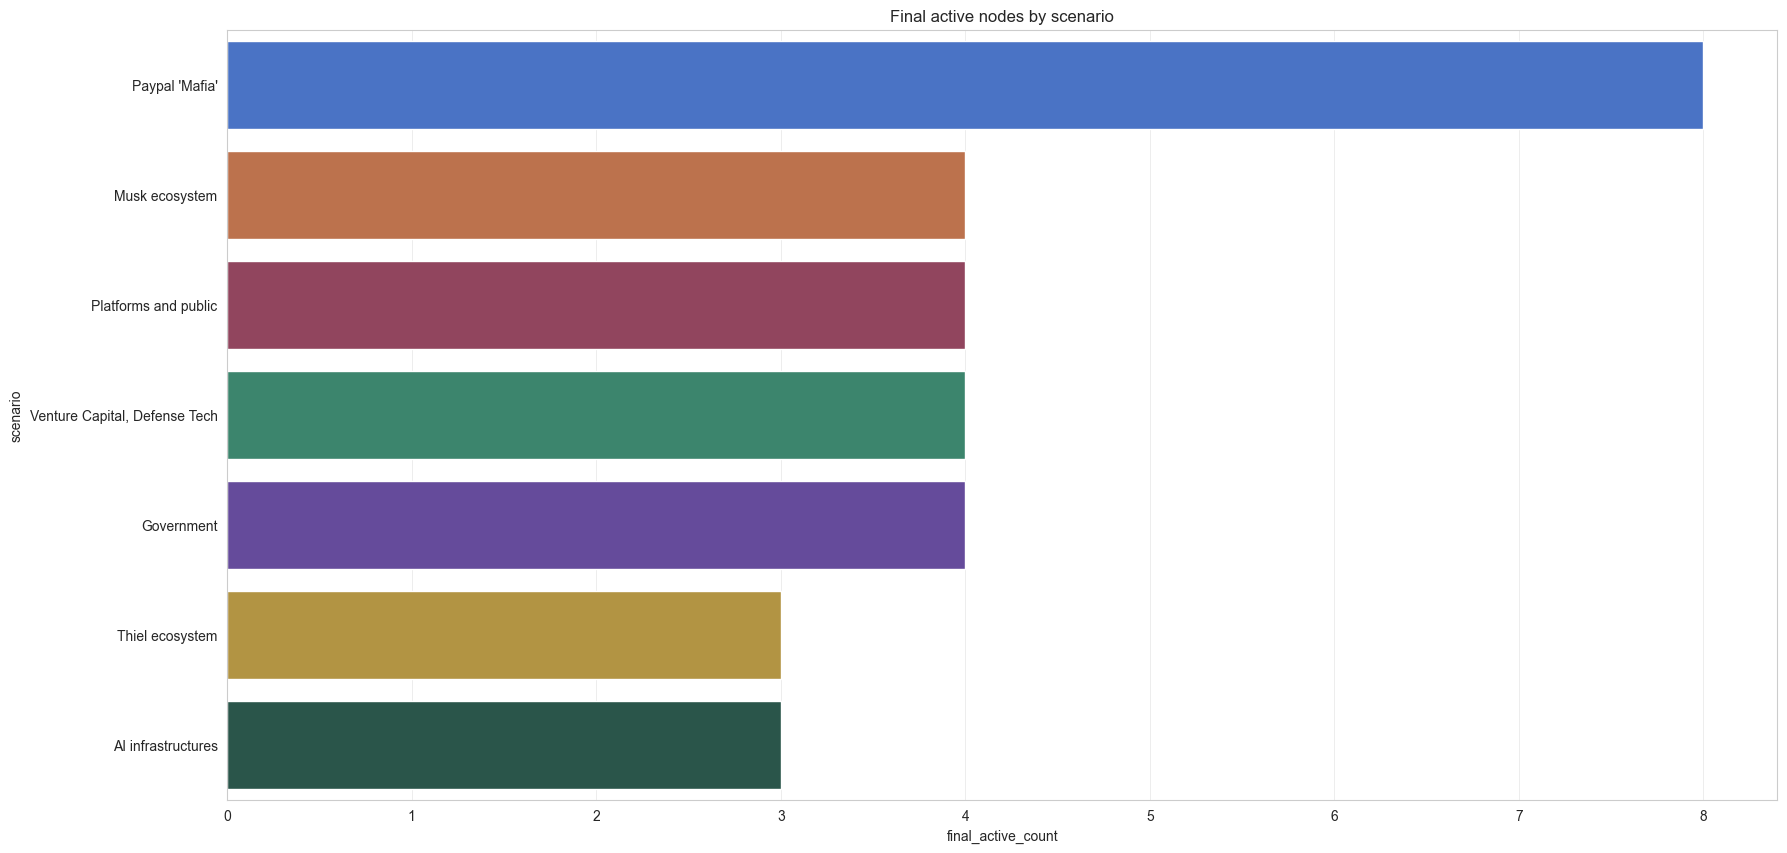

In [122]:
plt.figure(figsize=(20, 10))
sns.barplot(data=scenarios_results, y="scenario", x="final_active_count", hue="scenario")

sns.set_style("whitegrid")
plt.title("Final active nodes by scenario")
plt.show()

# Comparison with random baseline
We are looking at whether the Paypal Mafia seed diffuse further than 3 random seeds of the Network and if the cascades whill reach government or societal infrastructure nodes.

In [117]:
def random_baseline(G, seed_size=3, n_runs=1000):
    randomnodes= [n for n, attribute in G.nodes(data=True) if attribute["type"] == "person"]

    rows= []

    for run in range(n_runs):
        seeds = random.sample(randomnodes,seed_size)
        history, events, active = weighted_diffusion(G, seeds)
        government_nodes = [n for n in active if G.nodes[n]["group"] == "government_politics"]

        rows.append({
            "run": run,
            "seeds": ",".join(seeds),
            "final_active_count": len(active),
            "steps": int(history["step"].max()),
            "government_nodes_reached": len(government_nodes),
            "us_government_reached":int("US government" in active),
            "public_sphere_reached": int("Public" in active),
        })

    return pd.DataFrame(rows)

random_results = random_baseline(G, seed_size=3,n_runs=1000)
random_results.describe()

,run,final_active_count,steps,government_nodes_reached,us_government_reached,public_sphere_reached
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0
mean,499.500000,4.613000,0.917000,0.271000,0.0,0.0
std,288.819436,2.312267,1.173665,0.444699,0.0,0.0
min,0.000000,3.000000,0.000000,0.000000,0.0,0.0
25%,249.750000,3.000000,0.000000,0.000000,0.0,0.0
50%,499.500000,4.000000,1.000000,0.000000,0.0,0.0
75%,749.250000,5.000000,2.000000,1.000000,0.0,0.0
max,999.000000,16.000000,6.000000,1.000000,0.0,0.0


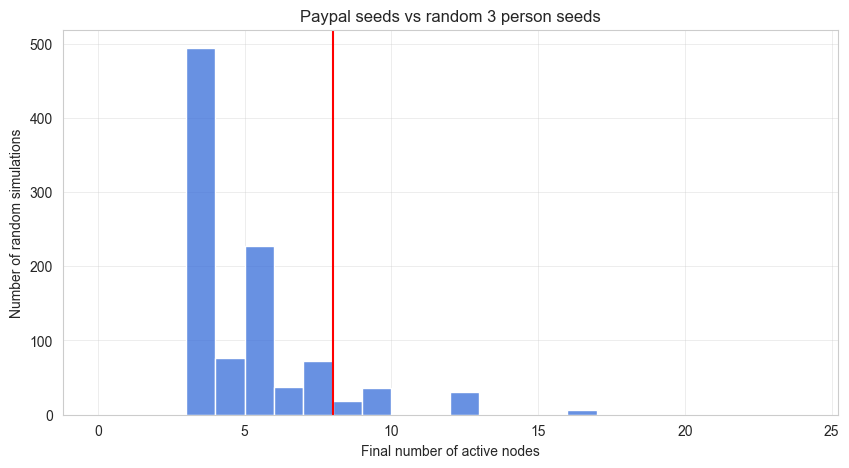

Paypal seed diffusion is larger than for random simulations :  90.7 %
Paypal seed diffusion is at least as large as or equal than random simulations :  92.60000000000001 %


In [128]:
paypal_final_count = len(paypal_active)
percent = (random_results["final_active_count"] < paypal_final_count).mean()*100
equallower = (random_results["final_active_count"] <= paypal_final_count).mean()*100

plt.figure(figsize=(10, 5))
sns.histplot(random_results["final_active_count"], bins=range(0,G.number_of_nodes()))

plt.axvline(paypal_final_count, color="red")
sns.set_style("whitegrid")
plt.title("Paypal seeds vs random 3 person seeds")
plt.xlabel("Final number of active nodes")
plt.ylabel("Number of random simulations")
plt.show()

print("Paypal seed diffusion is larger than for random simulations : ", percent,"%")
print("Paypal seed diffusion is at least as large as or equal than random simulations : ", equallower, "%")
